# Patch–Label Consistency Check: vinc dataset

Checks how well the annotation labels match the patches produced by:
1. **Old patchprep** — pre-computed cell masks, at `pax_ch_patch/patch_control_cell_insideoutside/`
2. **New patchprep (cio)** — on-the-fly segmentation, at `patches/cio/vinc/`
3. **New patchprep (dataset)** — on-the-fly segmentation, at `patches/dataset/vinc/`

**Filename key — both labels and patchprep use 0-indexed f-numbers; NO offset needed:**
- Label `crop_img_filename`: `f0001x0592y0560ps32.tif` (0-indexed f, no condition prefix)
- Patchprep `crop_img_filename`: `control_f0001x0592y0560ps32.tif` (0-indexed f, has prefix)
- Match key: `(fnum, x, y, ps)` from patchprep == `(fnum, x, y, ps)` from labels

In [1]:
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib_venn as mvenn

ROOT = Path('/home/lding/lding/fa_data_analysis')

# ── paths ─────────────────────────────────────────────────────────────────────
LABEL_CSV = ROOT / 'labelling/paxdata_paxpatch_batch1and2_combined_labels.csv'

OLD_PLOT_DIRS = {
    'control': ROOT / 'ae_results/pax_ch_patch/plot_control_cell_insideoutside',
    'ycomp'  : ROOT / 'ae_results/pax_ch_patch/plot_ycomp_cell_insideoutside',
}

NEW_PLOT_DIRS = {
    'cio': {
        'control': ROOT / 'ae_results/patches/cio/vinc/control/plot_patches32',
        'ycomp'  : ROOT / 'ae_results/patches/cio/vinc/ycomp/plot_patches32',
    },
    'dataset': {
        'control': ROOT / 'ae_results/patches/dataset/vinc/control/plot_patches32',
        'ycomp'  : ROOT / 'ae_results/patches/dataset/vinc/ycomp/plot_patches32',
    },
}

print('Label CSV:', LABEL_CSV.exists())
for norm, cds in NEW_PLOT_DIRS.items():
    for cond, d in cds.items():
        csvs = list(d.glob('*.csv')) if d.exists() else []
        print(f'  new/{norm}/{cond}: {len(csvs)} CSVs  (dir exists: {d.exists()})')

Label CSV: True
  new/cio/control: 50 CSVs  (dir exists: True)
  new/cio/ycomp: 41 CSVs  (dir exists: True)
  new/dataset/control: 51 CSVs  (dir exists: True)
  new/dataset/ycomp: 42 CSVs  (dir exists: True)


## 1. Helper: filename parser and CSV loader

In [2]:
_PAT = re.compile(r'f(\d+)x(\d+)y(\d+)ps(\d+)')

def parse_fname(fname: str):
    """Extract (fnum, x, y, ps) from a patch filename. Returns None if no match."""
    m = _PAT.search(fname)
    if m:
        return tuple(int(v) for v in m.groups())  # (fnum, x, y, ps)
    return None


def _numeric_key(csv_path: str) -> int:
    """Sort key: extract the trailing integer from 'f_0_to_N.csv'."""
    m = re.search(r'to_(\d+)', csv_path)
    return int(m.group(1)) if m else -1


def load_patchprep_csvs(plot_dirs: dict) -> pd.DataFrame:
    """Load all data_prep_record CSVs from a dict of {cond: plot_dir}.
    Uses the numerically-largest CSV per condition (= most complete cumulative run).
    Adds 'condition' column and normalised 'match_key' = (condition, fnum, x, y, ps).

    NOTE: both old and new patchprep use 0-indexed f-numbers, same as the label CSV.
    No offset is applied."""
    frames = []
    for cond, d in plot_dirs.items():
        d = Path(d)
        csvs = list(d.glob('data_prep_record*.csv'))
        if not csvs:
            print(f'  [WARN] no CSVs in {d}')
            continue
        # Sort numerically by the trailing N in 'to_N' to get the most-complete file last
        csvs_sorted = sorted(csvs, key=lambda p: _numeric_key(str(p)))
        df = pd.read_csv(csvs_sorted[-1])   # largest = most complete cumulative CSV
        df['condition'] = cond
        frames.append(df)
        print(f'  {cond}: {len(df):,} patches from {csvs_sorted[-1].name}')

    if not frames:
        return pd.DataFrame()

    df = pd.concat(frames, ignore_index=True)
    df = df.drop_duplicates(subset='crop_img_filename')

    # Parse filename → (fnum, x, y, ps) — no f-number offset needed
    parsed = df['crop_img_filename'].map(parse_fname)
    df['_fnum_raw'] = parsed.map(lambda t: t[0] if t else None)
    df['_x']        = parsed.map(lambda t: t[1] if t else None)
    df['_y']        = parsed.map(lambda t: t[2] if t else None)
    df['_ps']       = parsed.map(lambda t: t[3] if t else None)
    df['match_key'] = list(zip(
        df['condition'],
        df['_fnum_raw'],   # 0-indexed, same as labels — no +1 shift
        df['_x'], df['_y'], df['_ps']
    ))
    return df


def load_labels(csv_path: Path) -> pd.DataFrame:
    """Load label CSV, parse filename → match_key = (group, fnum, x, y, ps)."""
    df = pd.read_csv(csv_path)
    parsed = df['crop_img_filename'].map(parse_fname)
    df['_fnum'] = parsed.map(lambda t: t[0] if t else None)
    df['_x']    = parsed.map(lambda t: t[1] if t else None)
    df['_y']    = parsed.map(lambda t: t[2] if t else None)
    df['_ps']   = parsed.map(lambda t: t[3] if t else None)
    df['match_key'] = list(zip(
        df['group'], df['_fnum'], df['_x'], df['_y'], df['_ps']
    ))
    return df

## 2. Load label CSV

In [3]:
df_labels = load_labels(LABEL_CSV)
print(f'Labels: {len(df_labels):,} rows')
print(df_labels[['unique_ID','crop_img_filename','group','Position','classification']].head(5).to_string())
print()
print('Label group counts:')
print(df_labels['group'].value_counts())

Labels: 1,340 rows
                         unique_ID        crop_img_filename    group              Position classification
0  control-f0001x0592y0560ps32.tif  f0001x0592y0560ps32.tif  control             Cell Body    No adhesion
1  control-f0001x0688y0848ps32.tif  f0001x0688y0848ps32.tif  control               Lamella    No adhesion
2  control-f0001x0592y0592ps32.tif  f0001x0592y0592ps32.tif  control             Cell Body    No adhesion
3  control-f0001x0368y0528ps32.tif  f0001x0368y0528ps32.tif  control  Cell Periphery/other    No adhesion
4  control-f0001x0592y0528ps32.tif  f0001x0592y0528ps32.tif  control  Cell Periphery/other    No adhesion

Label group counts:
group
ycomp      949
control    391
Name: count, dtype: int64


## 3. Load old patchprep CSVs (pre-computed masks)

In [4]:
print('Old patchprep (pre-computed masks):')
df_old = load_patchprep_csvs(OLD_PLOT_DIRS)
print(f'  Total: {len(df_old):,} patches')
if not df_old.empty:
    print(df_old[['condition','crop_img_filename','match_key']].head(3).to_string())

Old patchprep (pre-computed masks):
  control: 12,912 patches from data_prep_record_czi_cell_insideoutside_ch1_f_0_to_49.csv
  ycomp: 10,744 patches from data_prep_record_czi_cell_insideoutside_ch1_f_0_to_40.csv
  Total: 23,656 patches
  condition                crop_img_filename                   match_key
0   control  control_f0000x0080y0816ps32.tif   (control, 0, 80, 816, 32)
1   control  control_f0000x0112y0784ps32.tif  (control, 0, 112, 784, 32)
2   control  control_f0000x0144y0784ps32.tif  (control, 0, 144, 784, 32)


## 4. Load new patchprep CSVs (on-the-fly segmentation)

In [5]:
df_new = {}
for norm in ('cio', 'dataset'):
    print(f'New patchprep ({norm}):')
    df = load_patchprep_csvs(NEW_PLOT_DIRS[norm])
    df_new[norm] = df
    if not df.empty:
        print(f'  Total: {len(df):,} patches')
    else:
        print(f'  Not yet generated — run: bash scripts/run_patchprep.sh --dataset vinc --norm {norm}')
    print()

New patchprep (cio):
  control: 13,365 patches from data_prep_record_control_ch1_f_0_to_49.csv
  ycomp: 11,064 patches from data_prep_record_ycomp_ch1_f_0_to_40.csv
  Total: 24,429 patches

New patchprep (dataset):
  control: 13,365 patches from data_prep_record_control_ch1_f_0_to_49.csv
  ycomp: 11,064 patches from data_prep_record_ycomp_ch1_f_0_to_40.csv
  Total: 24,429 patches



## 5. Match: labels ↔ old patchprep

In [6]:
label_keys = set(df_labels['match_key'])

def match_report(name: str, df_patch: pd.DataFrame):
    if df_patch.empty:
        print(f'{name}: not available')
        return {}

    patch_keys = set(df_patch['match_key'])
    in_both       = label_keys & patch_keys
    label_only    = label_keys - patch_keys
    patch_only    = patch_keys - label_keys

    print(f'{name}')
    print(f'  Total patches in patchprep : {len(patch_keys):>6,}')
    print(f'  Total labels               : {len(label_keys):>6,}')
    print(f'  Matched (in both)          : {len(in_both):>6,}  '
          f'({100*len(in_both)/len(label_keys):.1f}% of labels covered)')
    print(f'  Labels with no patch       : {len(label_only):>6,}  '
          f'(label exists, patch not generated)')
    print(f'  Patches with no label      : {len(patch_only):>6,}  '
          f'(patch exists, not labelled — expected)')
    return {'in_both': in_both, 'label_only': label_only, 'patch_only': patch_only}

res_old = match_report('Old patchprep (pre-computed masks)', df_old)

Old patchprep (pre-computed masks)
  Total patches in patchprep : 23,656
  Total labels               :  1,340
  Matched (in both)          :  1,340  (100.0% of labels covered)
  Labels with no patch       :      0  (label exists, patch not generated)
  Patches with no label      : 22,316  (patch exists, not labelled — expected)


## 6. Match: labels ↔ new patchprep (cio and dataset)

In [7]:
res_new = {}
for norm in ('cio', 'dataset'):
    res_new[norm] = match_report(f'New patchprep ({norm})', df_new[norm])
    print()

New patchprep (cio)
  Total patches in patchprep : 24,429
  Total labels               :  1,340
  Matched (in both)          :  1,325  (98.9% of labels covered)
  Labels with no patch       :     15  (label exists, patch not generated)
  Patches with no label      : 23,104  (patch exists, not labelled — expected)

New patchprep (dataset)
  Total patches in patchprep : 24,429
  Total labels               :  1,340
  Matched (in both)          :  1,325  (98.9% of labels covered)
  Labels with no patch       :     15  (label exists, patch not generated)
  Patches with no label      : 23,104  (patch exists, not labelled — expected)



## 7. Per-image patch count comparison

In [8]:
def per_image_counts(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Patch count per (condition, fnum) image."""
    if df.empty:
        return pd.DataFrame()
    df = df.copy()
    df['img_key'] = list(zip(df['condition'], df['_fnum_raw']))   # no +1: 0-indexed
    counts = df.groupby('img_key').size().reset_index(name=label)
    counts[['condition','fnum']] = pd.DataFrame(counts['img_key'].tolist(), index=counts.index)
    return counts[['condition','fnum', label]]

counts_old = per_image_counts(df_old, 'old')
counts_cio = per_image_counts(df_new.get('cio', pd.DataFrame()), 'new_cio')
counts_ds  = per_image_counts(df_new.get('dataset', pd.DataFrame()), 'new_dataset')

# Merge all on (condition, fnum)
merged = counts_old
for df_c in [counts_cio, counts_ds]:
    if not df_c.empty:
        merged = merged.merge(df_c, on=['condition','fnum'], how='outer')

merged = merged.sort_values(['condition','fnum']).reset_index(drop=True)
print('Patch count per image:')
print(merged.to_string())

Patch count per image:
   condition  fnum  old  new_cio  new_dataset
0    control     0  342      350          350
1    control     1  307      323          323
2    control     2  243      248          248
3    control     3  418      412          412
4    control     4  190      206          206
5    control     5  216      303          303
6    control     6  242      248          248
7    control     7  245      240          240
8    control     8  222      232          232
9    control     9  249      254          254
10   control    10  392      406          406
11   control    11  210      212          212
12   control    12  262      263          263
13   control    13  208      210          210
14   control    14  359      364          364
15   control    15  225      226          226
16   control    16  274      283          283
17   control    17  373      376          376
18   control    18  251      253          253
19   control    19  256      261          261
20   contro

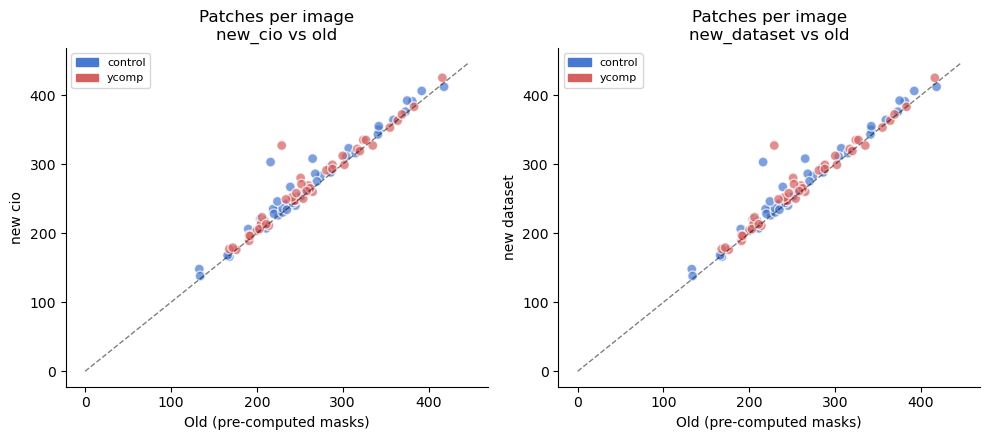

In [9]:
# Scatter: old vs new patch count per image (should be close if seg is consistent)
avail_new = [c for c in ('new_cio','new_dataset') if c in merged.columns]
if avail_new and 'old' in merged.columns:
    fig, axes = plt.subplots(1, len(avail_new), figsize=(5*len(avail_new), 4.5))
    if len(avail_new) == 1:
        axes = [axes]
    for ax, col in zip(axes, avail_new):
        sub = merged.dropna(subset=['old', col])
        colors = sub['condition'].map({'control':'#4878CF','ycomp':'#D65F5F'})
        ax.scatter(sub['old'], sub[col], c=colors, alpha=0.7, edgecolors='white', s=50)
        lim = max(sub['old'].max(), sub[col].max()) * 1.05
        ax.plot([0,lim],[0,lim], 'k--', lw=1, alpha=0.5)
        ax.set_xlabel('Old (pre-computed masks)')
        ax.set_ylabel(col.replace('_',' '))
        ax.set_title(f'Patches per image\n{col} vs old')
        ax.spines[['top','right']].set_visible(False)
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(color='#4878CF', label='control'),
            Patch(color='#D65F5F', label='ycomp'),
        ], fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print('New patchprep not yet available — run run_patchprep.sh first, then re-run this notebook.')

## 8. Venn diagram: label coverage

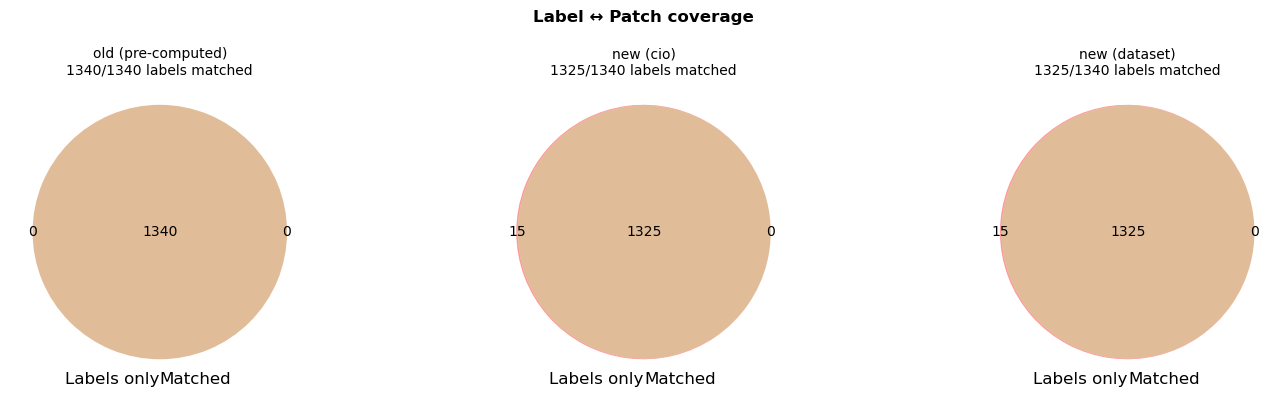

In [10]:
try:
    import matplotlib_venn as mvenn
    HAS_VENN = True
except ImportError:
    HAS_VENN = False
    print('matplotlib_venn not installed — pip install matplotlib-venn')

datasets_to_plot = [('old (pre-computed)', res_old)]
for norm in ('cio','dataset'):
    if res_new.get(norm):
        datasets_to_plot.append((f'new ({norm})', res_new[norm]))

if HAS_VENN and len(datasets_to_plot) >= 1:
    fig, axes = plt.subplots(1, len(datasets_to_plot), figsize=(5*len(datasets_to_plot), 4))
    if len(datasets_to_plot) == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, datasets_to_plot):
        if not res:
            ax.axis('off')
            continue
        n_labels   = len(label_keys)
        n_matched  = len(res['in_both'])
        n_lonly    = len(res['label_only'])
        mvenn.venn2(
            subsets=(n_lonly, 0, n_matched),
            set_labels=('Labels only', 'Matched'),
            ax=ax,
        )
        ax.set_title(f'{name}\n{n_matched}/{n_labels} labels matched', fontsize=10)

    plt.suptitle('Label ↔ Patch coverage', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    # Fallback: simple bar chart
    names, matched, missed = [], [], []
    for name, res in datasets_to_plot:
        if res:
            names.append(name)
            matched.append(len(res['in_both']))
            missed.append(len(res['label_only']))

    if names:
        x = np.arange(len(names))
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.bar(x, matched, label='Matched',        color='#4878CF')
        ax.bar(x, missed,  label='Labels only',    color='#D65F5F', bottom=matched)
        ax.set_xticks(x); ax.set_xticklabels(names, fontsize=9)
        ax.set_ylabel('Patch count')
        ax.set_title('Label coverage by patchprep version')
        ax.legend(fontsize=9)
        ax.spines[['top','right']].set_visible(False)
        plt.tight_layout()
        plt.show()

## 9. Inspect unmatched labels
Labels that exist in the annotation file but have no corresponding patch in a given patchprep.

In [11]:
def show_unmatched(name: str, res: dict, df_lab: pd.DataFrame, n: int = 10):
    if not res or not res.get('label_only'):
        print(f'{name}: no unmatched labels')
        return
    unmatched = df_lab[df_lab['match_key'].isin(res['label_only'])]
    print(f'{name}: {len(unmatched)} unmatched labels')
    print('  classification breakdown:')
    print(unmatched['classification'].value_counts().to_string())
    print('  Position breakdown:')
    print(unmatched['Position'].value_counts().to_string())
    print('  Sample rows:')
    print(unmatched[['unique_ID','group','Position','classification']].head(n).to_string())
    print()

show_unmatched('Old (pre-computed masks)', res_old, df_labels)
for norm in ('cio','dataset'):
    if res_new.get(norm):
        show_unmatched(f'New ({norm})', res_new[norm], df_labels)

Old (pre-computed masks): no unmatched labels
New (cio): 15 unmatched labels
  classification breakdown:
classification
No adhesion         9
focal complex       3
focal adhesion      2
Nascent Adhesion    1
  Position breakdown:
Position
Cell Periphery/other     9
Cell Protruding Edge     5
No Category/uncertain    1
  Sample rows:
                           unique_ID    group               Position    classification
7    control-f0012x0976y0464ps32.tif  control   Cell Protruding Edge       No adhesion
94   control-f0016x0528y0528ps32.tif  control   Cell Periphery/other       No adhesion
222    ycomp-f0004x0496y0592ps32.tif    ycomp  No Category/uncertain       No adhesion
398  control-f0003x0912y0912ps32.tif  control   Cell Periphery/other    focal adhesion
447  control-f0014x0944y0720ps32.tif  control   Cell Periphery/other    focal adhesion
589    ycomp-f0002x0944y0368ps32.tif    ycomp   Cell Periphery/other       No adhesion
714    ycomp-f0008x0528y0336ps32.tif    ycomp   Cell Per

## 10. Summary

In [12]:
rows = []
all_results = [('old (pre-computed masks)', res_old)] + [
    (f'new ({n})', res_new[n]) for n in ('cio','dataset') if res_new.get(n)
]
for name, res in all_results:
    if not res:
        continue
    rows.append({
        'patchprep'          : name,
        'labels_total'       : len(label_keys),
        'matched'            : len(res['in_both']),
        'label_coverage_%'   : round(100 * len(res['in_both']) / len(label_keys), 1),
        'labels_missing'     : len(res['label_only']),
        'patches_unlabelled' : len(res['patch_only']),
    })

summary = pd.DataFrame(rows)
print('=== Summary ===')
print(summary.to_string(index=False))

=== Summary ===
               patchprep  labels_total  matched  label_coverage_%  labels_missing  patches_unlabelled
old (pre-computed masks)          1340     1340             100.0               0               22316
               new (cio)          1340     1325              98.9              15               23104
           new (dataset)          1340     1325              98.9              15               23104
